# Fisher-vs-MCMC cross-check: PFS $P_\ell + B_0$ + DESI DR2 BAO + BBN+$n_s$ ($\Lambda$CDM)

BlackJAX NUTS posterior on the **same forecast likelihood** as
`fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb`, to test whether the Fisher
(Gaussian) forecast is consistent with the full posterior.

**Setup (matches the Fisher notebook exactly):**
- PFS full-shape $P_\ell(k) + B_0$ (7 bins, AP), DESI DR2 BAO, BBN + $n_{s,10}$ + EFT/stochastic priors.
- **Noiseless mock**: the "data" is the fiducial theory vector, so the posterior is centred at the
  fiducial and its width/shape directly test the Fisher approximation.
- **Sample the full varied block** (cosmology + per-bin EFT/survey params, minus the fixed ones) —
  the same block the Fisher marginalises — then compare the marginal cosmology posterior to the
  Fisher cosmology block.
- **EFT/stochastic priors: the DESI DR1-reanalysis spec** (`desi_dr1_reanalysis_2511_20757`,
  arXiv:2511.20757 Table I) with runtime $A_{\rm AP}A_{\rm amp}$ rescaling and the correlated
  per-bin counterterm block — see the prior section below for the mean-vs-mode caveat.
- **Whitening** uses the prior-included (legacy-spec) Fisher as the **proposal geometry only**.

> Runtime: the P+B theory ($n_\mu=n_\phi=65$, 7 bins) is evaluated on every gradient step, so a
> production chain is expensive (hours). `SMOKE_TEST=True` runs a tiny chain first to validate the
> pipeline end-to-end in minutes; set it to `False` for a science run.

In [1]:
from functools import partial
import os
import time

N_THREADS = os.cpu_count() or 1
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = str(N_THREADS)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-jaxptpolypol")

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
plt.rcParams.update({
    "text.usetex": True, "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern", "font.size": 22})

import numpy as np
from tqdm.auto import tqdm

import jax
jax.config.update("jax_enable_x64", True)

# Persistent XLA compilation cache: repeated notebook runs reuse compiled graphs
import pathlib as _pathlib
jax.config.update("jax_compilation_cache_dir", str(_pathlib.Path.home() / ".jax_xla_cache"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 10)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol import (
    split_marginal_indices, bin_lin_slices,
    make_marginal_log_posterior_perbin,
)
from jaxptpolypol.desi_priors import (
    load_desi_prior_spec, make_desi_prior_fns, make_lcdm_rescaling_fns,
)
from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import CosmoParams, FullShapeSurveyParams, pack_joint_params
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid, compute_fiducial_distances,
    make_gaussian_joint_covariance_fn, make_joint_pk_bk_fn,
    make_joint_pk_bk_bin_fn,
)
from jaxptpolypol.bao import (
    load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher, make_bao_theory_fn,
)
from jaxptpolypol.priors import load_prior_spec, build_prior_sigmas_from_spec
from jaxptpolypol.inference import (
    fisher_matrix, marginalize_fisher, marginalized_fisher_block,
    fixed_and_varied_indices, gaussian_prior_fisher,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.chain_analysis import (
    make_fullshape_spec, packed_samples_to_dict, scalar_summary_packed, plot_trace,
)
from jaxptpolypol.sampler import (
    make_transform, make_cholesky_transform, make_full_params_fn, make_gaussian_log_prior,
    make_log_posterior, run_nuts, run_rwmh, run_rwmh_python, samples_to_physical,
)


## Configuration (mirrors the Fisher notebook)

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561,
}
MNU_FIXED = 0.06  # eV, not varied in LCDM

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (identical to the Fisher notebook) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'
BACKGROUND_MODE = 'direct'

PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── Forecast (cosmology) basis and priors ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])
COSMO_PRIORS = {'ombh2': 0.00055, 'ns': 0.042}  # BBN + ns10 (arXiv:2411.12022)
MODEL_TITLE = r'$\Lambda$CDM'

# ── MCMC run mode ──
SMOKE_TEST = True   # tiny chain to validate the pipeline end-to-end; set False for production
# PRODUCTION sampling runs gradient-based NUTS on the prior-independent Taylor
# surrogate (validated: DESI-prior gate widths 0.986-1.014 & max |Dcorr| 0.021
# vs Hessian-Fisher; NUTS-on-surrogate R-hat <= 1.0002, 0 divergences; fiducial
# identity surrogate lp0 == exact lp0 == -172.996046). The exact per-bin RWMH
# (gradient-free MH, arXiv:2511.20757) is retained as the SMOKE gate: NUTS grad
# of the EXACT marginal posterior is a second-order XLA graph that exhausts
# memory, whereas the surrogate body is tiny dense algebra where NUTS is the
# right tool (docs/design/perbin-compile-measurements.md).
NUTS_SEED = 20260731                             # matches scripts/taylor_surrogate_nuts.py
NUTS_SHAKE_WARMUP, NUTS_SHAKE_DRAWS = 100, 200   # smoke-only surrogate NUTS shakedown (seconds)
if SMOKE_TEST:
    # Exact per-bin RWMH smoke gate: at ~5.7 s/step this 60-step chain takes
    # ~6 min end-to-end, plus a seconds-scale surrogate NUTS shakedown.
    NUM_SAMPLES_MH, NUM_BURN_MH, NUM_CHAINS = 60, 10, 1
else:
    # Production NUTS-on-surrogate (taylor_surrogate_nuts.py-validated settings,
    # ~minutes) REPLACES the former 150k-step exact RWMH (~10 days of forward
    # stepping at ~5.7 s/step).
    NUTS_WARMUP, NUTS_DRAWS, NUTS_CHAINS = 1000, 5000, 4


## Emulator, models, fiducial parameters

In [3]:
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'], 'h': FIDUCIAL['h'],
    'z': 0.7, 'A_b': 3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias / counterterm fiducials (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=MNU_FIXED))
def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

surveys = []
for z, knl, nd in zip(z_bins, knl_bins, n_bar):
    surveys.append(FullShapeSurveyParams(
        shared={'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
                'stoch': {'P_shot': 1.0}, 'k_nl': knl, 'ndens': nd},
        pk={'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.}},
        bk={'ctr': {'c1': 0.0}, 'stoch': {'B_shot': 1.0, 'A_shot': 1.0}},
    ))
joint_survey_keys = surveys[0].joint_param_keys
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)
print(f"Packed params: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}x{n_zbins} survey)")

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Packed params: 121 (9 cosmo + 16x7 survey)


## Joint P+B theory, covariance, and the data Fisher

In [4]:
# Single source of truth for the theory configuration: the monolithic joint_fn
# (used for the mock data vector and the Fisher) and the per-bin theory closures
# in the likelihood cell below MUST agree, or the "noiseless" mock stops being
# noiseless and the posterior is silently biased.
joint_theory_kwargs = dict(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model, bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    n_gl=N_GL, num_mu=NUM_MU, num_phi=NUM_PHI, background_mode=BACKGROUND_MODE)
joint_fn = make_joint_pk_bk_fn(**joint_theory_kwargs)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL, n_gl=N_GL, background_mode=BACKGROUND_MODE)
jitted_joint_fn = jax.jit(joint_fn)

k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0]); n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk)
n_tri = int(triangles.shape[0])
print(f"P grid n_k={n_k}, dk={dk:.5f}; B triangles={n_tri}; per-bin block=3*{n_k}+{n_tri}")

jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
gauss_cov = joint_cov_fn(packed_params, V_survey=V_bins, k=k, dk=dk,
                         triangles=triangles, triangle_dk=triangle_dk)
F_pfs_full = fisher_matrix(gauss_cov, jac)
print("PFS P+B Fisher:", F_pfs_full.shape)

P grid n_k=37, dk=0.00500; B triangles=264; per-bin block=3*37+264


CPU times: user 14min 13s, sys: 4min 1s, total: 18min 14s
Wall time: 2min 26s


PFS P+B Fisher: (121, 121)


## DESI DR2 BAO: Fisher block + differentiable likelihood

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

# Fisher block (matches the Fisher notebook)
F_bao = bao_fisher_matrix(bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

# Differentiable BAO theory over the packed cosmology block (for the MCMC likelihood)
bao_theory_fn = make_bao_theory_fn(bao_dr2,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, mnu_fixed=MNU_FIXED)
print("BAO data points:", len(bao_dr2.data_points), "| F_bao:", F_bao.shape)

BAO data points: 13 | F_bao: (9, 9)


## Priors: EFT/stochastic spec + BBN + $n_{s,10}$

In [6]:
prior_spec = load_prior_spec('eft_eq12_2405_02252')
prior_sigmas = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, observable='joint', spec=prior_spec, cosmo_priors=COSMO_PRIORS)
# bGamma3 ~ N(fid, 1^2) (arXiv:2511.20757 Table I): required proper prior for
# analytic marginalization; added to BOTH the Fisher and the MCMC sides.
bgamma3_off = joint_survey_keys.index(('shared', 'bias', 'bGamma3'))
for b in range(n_zbins):
    prior_sigmas[n_cosmo_params + b * n_survey_params + bgamma3_off] = 1.0
F_prior = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior
print(f"Prior entries: {len(prior_sigmas)} params (BBN ombh2, ns10 ns, EFT/stochastic survey)")

Prior entries: 79 params (BBN ombh2, ns10 ns, EFT/stochastic survey)


## Varied block, comparison Fisher, and whitening scales

In [7]:
# Fixed (removed): cosmo z/A_b/eta_b/logT_AGN and per-bin k_nl, ndens.
# Sampled block theta_NL = varied cosmology + per-bin (b1, b2, bG2);
# the 11 linear EFT/stochastic params per bin are marginalized analytically
# (arXiv:2511.20757 Table I; see CONTEXT.md "c1 FoG counterterm").
fixed_cosmo = [5, 6, 7, 8]
split = split_marginal_indices(
    n_cosmo_params=n_cosmo_params, survey_keys=joint_survey_keys, n_bins=n_zbins,
    fixed_cosmo=fixed_cosmo,
    fixed_survey_keys={('shared', 'k_nl', None), ('shared', 'ndens', None)})
n_nl = split.n_nl
varied_idx = sorted(list(split.nl_idx) + list(split.lin_idx))   # same set as before

cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
nl_pos = {full_idx: pos for pos, full_idx in enumerate(split.nl_idx)}
cosmo_nl_pos = [nl_pos[i] for i in cosmo_varied_global]         # cosmo positions in theta_NL

# Comparison Fisher: UNCHANGED — full-space Fisher + priors, marginalized to cosmology.
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_full, varied_idx),
    [varied_idx.index(i) for i in cosmo_varied_global])

# Whitening for the SAMPLED block: Schur the prior-included Fisher down to theta_NL.
F_varied_prior = marginalize_fisher(F_pfs_bao_prior_full, varied_idx)
nl_in_varied = [varied_idx.index(i) for i in split.nl_idx]
F_nl_prior = marginalized_fisher_block(F_varied_prior, nl_in_varied)
fisher_sigma_nl = jnp.sqrt(jnp.diag(inv(F_nl_prior)))
fid_nl = packed_params[jnp.array(split.nl_idx)]
print(f"n_NL = {n_nl} ({len(cosmo_varied_global)} cosmo + {3 * n_zbins} bias), "
      f"n_lin marginalized = {split.n_lin}")


n_NL = 26 (5 cosmo + 21 bias), n_lin marginalized = 77


## Combined likelihood, whitening transform, and log-posterior

### Priors: DESI DR1-reanalysis spec (`desi_dr1_reanalysis_2511_20757`)

The marginalized-block (θ_lin) and sampled-bias priors below come from the packaged
arXiv:2511.20757 Table I spec via `make_desi_prior_fns` — replacing the earlier
fiducial-centered Fisher-consistent placeholders. Two things to know when reading results:

- **The c0/c2/c4 counterterm prior is the paper's per-multipole prior**, carried in our
  μ-space (tilde) basis as a **correlated per-bin covariance block** Σ_p = L(f)·diag(σ²)·Lᵀ
  (cov-mode; convention map: `docs/design/desi-convention-map.md`). This representation was
  validated against the independent rotated-basis implementation at
  max|Δlog post| = 4.2×10⁻¹² (`docs/design/perbin-compile-measurements.md`, "Task E").
- **Mean-vs-mode** (CONTEXT.md methodology rule): with these θ_NL-dependent prior widths
  (A_AP·A_amp rescaling, b2/bG2 ∝ 1/σ8²) the posterior MEAN sits below the MODE — ≈1.1 σ_F
  on logA at the production configuration (≈⅓ from the width-volume effect, the rest
  intrinsic marginal-posterior curvature; see the frozen-R diagnostic). This is expected
  physics, not a bug: compare Fisher against the mode/tilted center, and read mean-based
  summaries accordingly.

The BBN(ω_b) + n_s,10 cosmology priors are unchanged; the legacy-spec Fisher/whitening
matrix is retained **as the MH proposal only** (the proposal need not match the target).

In [8]:
# Combined (noiseless) forecast data vector: P+B ++ BAO, both at the fiducial.
pb_fid = jitted_joint_fn(packed_params, k=k, triangles=triangles)
bao_fid = bao_theory_fn(fiducial_cosmo)

# --- Exact per-bin factorization of the marginalized likelihood ---------------
# gauss_cov is block diagonal across redshift bins (covariance.py) and each bin's
# theory depends only on its own theta_lin, so the dense n_lin x n_lin
# marginalization splits into a sum of per-bin ones: same posterior value,
# 12.9x faster per evaluation at 3.3x lower peak RSS (7 bins, production
# grids). BAO carries no theta_lin dependence and enters once as
# a plain -0.5 r^T Cinv r term.
block_len = 3 * n_k + n_tri
bin_theory_fns = [
    partial(make_joint_pk_bk_bin_fn(bin_index=b, **joint_theory_kwargs),
            k=k, triangles=triangles)
    for b in range(n_zbins)]
bin_blocks = [slice(b * block_len, (b + 1) * block_len) for b in range(n_zbins)]
bin_data = [pb_fid[sl] for sl in bin_blocks]
bin_cov_invs = [inv(gauss_cov[sl, sl]) for sl in bin_blocks]   # per-block inverse
bin_lin_idx = [split.lin_idx[sl] for sl in bin_lin_slices(split, n_zbins)]
bao_cov_inv = inv(jnp.asarray(bao_dr2.cov))

# --- DESI DR1-reanalysis priors (arXiv:2511.20757 Table I) --------------------
# One spec drives both parameter blocks (CONTEXT.md Stream-B decision 3):
#  - marginalized block: mu_p(theta_NL), Sigma_p(theta_NL) with the runtime
#    A_AP*A_amp rescaling, the bGamma3 coevolution mean, the per-bin
#    (knl_b/0.45)^2 a0/a2 widths, and the CORRELATED c0/c2/c4 block
#    L(f)*diag(sigma_paper^2)*L(f)^T (cov-mode: prior_sigma_fn returns
#    stacked (n_bins, 11, 11) covariance blocks -- consumed natively by
#    make_marginal_log_posterior_perbin);
#  - sampled block: b2/bG2 ~ N(0, (5/sigma8(z)^2)^2), b1 flat.
# The rescaling closures mirror the validated gate script
# (scripts/desi_prior_validation.py): 5-key sampled cosmology basis with the
# fixed baryon-feedback emulator inputs injected as fiducial constants.
desi_spec = load_desi_prior_spec()          # desi_dr1_reanalysis_2511_20757
FIXED_BARYON = {'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                'logT_AGN': cosmo_dict['logT_AGN']}
sigma8_bins_fn, a_ap_bins_fn, sigma8_ref_bins = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator, cosmo_keys=SHARED_KEYS,
    cosmo_sizes=(1,) * N_SHARED, z_bins=z_bins,
    fid_cosmo_native=fid_nl[:N_SHARED], mnu_fixed=MNU_FIXED,
    fixed_cosmo_extras=FIXED_BARYON)
prior_mean_fn, prior_sigma_fn, log_prior_nl_desi = make_desi_prior_fns(
    desi_spec, split=split, knl_bins=knl_bins,
    sigma8_bins_fn=sigma8_bins_fn, a_ap_bins_fn=a_ap_bins_fn,
    sigma8_ref_bins=sigma8_ref_bins)

# --- Sampled-block cosmology priors (BBN ombh2 + ns10, unchanged) -------------
# Bias priors (b2/bG2) now come from the spec via log_prior_nl_desi above, so
# only the COSMOLOGY entries of prior_sigmas enter here -- no double counting.
nl_prior_entries = [
    (nl_pos[i], float(packed_params[i]), prior_sigmas[i])
    for i in cosmo_varied_global if i in prior_sigmas
]
log_prior_nl_cosmo = make_gaussian_log_prior(n_nl, nl_prior_entries)
def log_prior_nl(theta_nl):
    return log_prior_nl_cosmo(theta_nl) + log_prior_nl_desi(theta_nl)

# Whitening + full-vector reconstruction for the sampled block only.
# Full Fisher-Cholesky whitening (NOT diagonal): the cosmology block is strongly
# correlated, and diagonal whitening left the whitened posterior so anisotropic
# that isotropic 2.38/sqrt(d) RWMH proposals were rejected 60/60. With
# L L^T = inv(F_nl_prior) the whitened target is ~unit-isotropic by construction.
# NOTE: F_nl_prior is built from the LEGACY prior spec -- kept deliberately as
# the MH PROPOSAL geometry only (MH is exact for any proposal); the TARGET
# priors are the DESI spec above.
cov_nl_prior = inv(F_nl_prior)
to_whitened, to_physical = make_cholesky_transform(center=fid_nl, cov=cov_nl_prior)
full_params_fn = make_full_params_fn(packed_params, split.nl_idx)

log_post = make_marginal_log_posterior_perbin(
    bin_theory_fns=bin_theory_fns, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    bin_lin_idx=bin_lin_idx,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

x0 = jnp.zeros(n_nl)


In [9]:
# Forward gate: first (compiling) evaluation of the factorized log-posterior.
# The dense monolith is deliberately NOT built here for a cross-check -- that
# needs a second full n_zbins-bin compile; perbin == monolith at rtol=1e-10 is
# asserted by tests/test_marginal_perbin.py.
print(f"n_NL = {n_nl}, n_lin = {split.n_lin} "
      f"({split.n_lin // n_zbins}/bin), block_len = 3*{n_k}+{n_tri} = {block_len}")
print(f"per bin: data {tuple(bin_data[0].shape)}, cov_inv {tuple(bin_cov_invs[0].shape)}, "
      f"lin_idx {len(bin_lin_idx[0])} x {n_zbins} bins")
print(f"BAO: data {tuple(bao_fid.shape)}, cov_inv {tuple(bao_cov_inv.shape)}")
print(f"DESI prior blocks: Sigma_p(fid) {tuple(prior_sigma_fn(fid_nl).shape)} (cov-mode)")

_t0 = time.perf_counter()
lp0 = float(jax.block_until_ready(log_post(x0)))
_dt = time.perf_counter() - _t0
# Under the DESI spec the prior MEANS are non-fiducial (c2 -> 30, cfog -> 400,
# P/B/A_shot centering, bGamma3 coevolution), so lp0 contains genuine prior
# residual terms on top of the -0.5*logdet(A Sigma_p) normalization -- it is
# NOT the pure-logdet value of the legacy fiducial-centered setup.
print(f"log_post(x0) = {lp0:.6f}  (logdet + non-fiducial DESI prior residuals); "
      f"first call trace+compile+eval {_dt:.1f} s")
assert np.isfinite(lp0)


n_NL = 26, n_lin = 77 (11/bin), block_len = 3*37+264 = 375
per bin: data (375,), cov_inv (375, 375), lin_idx 11 x 7 bins
BAO: data (13,), cov_inv (13, 13)


DESI prior blocks: Sigma_p(fid) (7, 11, 11) (cov-mode)


log_post(x0) = -172.996046  (logdet + non-fiducial DESI prior residuals); first call trace+compile+eval 56.2 s


## Production sampling: Taylor surrogate

**Production sampling now runs gradient-based NUTS on the prior-independent Taylor surrogate** (`cache/taylor_templates_lcdm.npz`) rather than the exact per-bin RWMH. The exact per-bin `log_post` built above is retained unchanged as the **smoke gate** and the ground-truth definition of the posterior.

Why the promotion is safe (all validated):

- **Fiducial identity** — the surrogate is *exact at its expansion point*, so at the fiducial it reproduces the exact-path value: `log_post_surr(x0) == log_post(x0) == -172.996046` (asserted in the next cell).
- **DESI-prior gate** — under these DESI priors the surrogate posterior matches the Hessian-Fisher: cosmology-block widths ratio 0.986–1.014, max |Δcorr| 0.021 (`scripts/desi_prior_validation.py`).
- **Cross-representation equivalence** — max |Δ log-posterior| across the two template representations 4.2e-12.
- **NUTS-on-surrogate** — R-hat ≤ 1.0002, 0 divergences, mean acceptance 0.90 (`scripts/taylor_surrogate_nuts.py`).

The surrogate body is microsecond-scale dense algebra (linear templates + logdet tilt + Gaussian priors), so the scan-trap that forced gradient-free RWMH on the exact per-bin path does **not** apply to it (see `docs/design/perbin-compile-measurements.md`). Production therefore drops from **~10 days** of exact-path RWMH stepping (150k steps at ~5.7 s/step) to **~minutes** of NUTS on the surrogate.

In [10]:
# Production surrogate: load the prior-independent Taylor templates and build the
# surrogate marginal log-posterior with the SAME priors / extra (BAO) terms /
# whitening / full-vector map as the exact per-bin `log_post` above. The surrogate
# is exact at its expansion point, so at the fiducial (x0) it must reproduce the
# exact-path lp0 to the float64 floor -- assert that identity.
import sys as _sys, pathlib as _pathlib
_sys.path.insert(0, str(_pathlib.Path("scripts").resolve()))
from stream_common import META            # theory-config stamp (single source of truth)
from jaxptpolypol import (
    load_taylor_templates, make_marginal_log_posterior_taylor,
)

# expect_meta=META is the stale-template guard. The cached npz's stored meta
# matches META key-for-key here, so it loads silently; a cache predating the newer
# theory-config keys would warn-and-load (backward compat) instead of erroring.
_tt = load_taylor_templates("cache/taylor_templates_lcdm.npz", expect_meta=META)

log_post_surr = make_marginal_log_posterior_taylor(
    _tt, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

lp0_surr = float(jax.block_until_ready(log_post_surr(x0)))
print(f"exact-path lp0 = {lp0:.6f}")
print(f"surrogate  lp0 = {lp0_surr:.6f}")
print(f"|surrogate - exact| = {abs(lp0_surr - lp0):.3e}")
assert abs(lp0_surr - lp0) < 1e-6, (
    f"surrogate not exact at fiducial: {lp0_surr} vs {lp0}")

exact-path lp0 = -172.996046
surrogate  lp0 = -172.996046
|surrogate - exact| = 2.757e-12


## Run random-walk MH (Fisher-whitened, isotropic 2.38/sqrt(d) proposal)

Gradient-free Metropolis-Hastings, as in the DESI DR1 reanalysis (arXiv:2511.20757, Montepython MH):
the marginal posterior needs only forward evaluations, avoiding the second-order XLA graph
that `grad(log_post)` (NUTS) requires, which exhausts memory on the 7-bin P+B model.

In [11]:
%%time
if SMOKE_TEST:
    # ── Smoke gate: EXACT per-bin RWMH tiny chain (ground-truth path) ──
    rng_key = jax.random.key(42)
    sample_bar = tqdm(total=NUM_CHAINS * NUM_SAMPLES_MH,
                      desc="RWMH sampling (exact per-bin)", position=0)
    def on_sample(chain_idx, num_chains, done, total):
        sample_bar.n = (chain_idx - 1) * total + done
        sample_bar.refresh()
    try:
        samples_w, diagnostics = run_rwmh_python(
            rng_key, log_post, initial_position=x0,
            num_samples=NUM_SAMPLES_MH, num_chains=NUM_CHAINS,
            sample_progress_fn=on_sample)
    finally:
        sample_bar.close()
    samples_w = samples_w[:, NUM_BURN_MH:, :]     # discard burn-in (no warmup in RWMH)
    print("exact-path samples (post burn-in):", samples_w.shape)
    print("acceptance per chain:", np.asarray(diagnostics['acceptance_rate']))

    # Surrogate NUTS shakedown: confirm gradient-based sampling on the surrogate
    # runs end-to-end (tiny; seconds). Separate vars -- does NOT clobber the
    # exact-path samples_w/diagnostics the smoke analysis below consumes.
    _shake_w, _shake_diag = run_nuts(
        jax.random.key(NUTS_SEED), log_post_surr, x0,
        num_warmup=NUTS_SHAKE_WARMUP, num_samples=NUTS_SHAKE_DRAWS,
        num_chains=1, max_tree_depth=10)
    print(f"surrogate NUTS shakedown: samples {tuple(_shake_w.shape)}, "
          f"mean accept {float(np.mean(np.asarray(_shake_diag['acceptance_rate']))):.3f}, "
          f"divergences {int(np.sum(np.asarray(_shake_diag['is_divergent'])))}")
else:
    # ── Production: NUTS on the Taylor SURROGATE (validated settings) ──
    warm_bar = tqdm(total=NUTS_CHAINS, desc="NUTS warmup", position=0)
    sample_bar = tqdm(total=NUTS_CHAINS * NUTS_DRAWS, desc="NUTS sampling", position=1)
    def on_warm(c, nc, stage, done, total):
        if stage == "window_adaptation" and done == total:
            warm_bar.n = c; warm_bar.refresh()
    def on_sample(c, nc, done, total):
        sample_bar.n = (c - 1) * total + done; sample_bar.refresh()
    try:
        samples_w, diagnostics = run_nuts(
            jax.random.key(NUTS_SEED), log_post_surr, x0,
            num_warmup=NUTS_WARMUP, num_samples=NUTS_DRAWS, num_chains=NUTS_CHAINS,
            max_tree_depth=10,
            warmup_progress_fn=on_warm, sample_progress_fn=on_sample)
    finally:
        warm_bar.close(); sample_bar.close()
    # run_nuts returns post-warmup samples already, shape (chains, draws, n_nl) --
    # same contract as run_rwmh_python, so the analysis cells consume it as-is.
    print("production NUTS-on-surrogate samples:", samples_w.shape)
    print(f"mean acceptance {float(np.mean(np.asarray(diagnostics['acceptance_rate']))):.3f}; "
          f"divergence frac {float(np.mean(np.asarray(diagnostics['is_divergent']))):.4f}")

RWMH sampling (exact per-bin):   0%|          | 0/60 [00:00<?, ?it/s]

exact-path samples (post burn-in): (1, 50, 26)
acceptance per chain: [0.3]


surrogate NUTS shakedown: samples (1, 200, 26), mean accept 0.831, divergences 0
CPU times: user 1h 8min 3s, sys: 3min 47s, total: 1h 11min 50s
Wall time: 6min 7s
Compiler : 157 ms


In [12]:
if SMOKE_TEST or 'proposal_sigma' in diagnostics:
    # RWMH (exact per-bin smoke chain): acceptance is a per-chain scalar.
    acc = np.asarray(diagnostics['acceptance_rate'])
    print(f"acceptance per chain = {np.round(acc, 3)} (RWMH optimal ~0.234)")
    assert np.all((acc > 0.05) & (acc < 0.7)), "acceptance far from RWMH-usable range"
else:
    # NUTS-on-surrogate (production): acceptance is per-draw (target ~0.8).
    acc = np.asarray(diagnostics['acceptance_rate'])
    print(f"NUTS mean acceptance = {acc.mean():.3f}; divergence frac = "
          f"{np.mean(np.asarray(diagnostics['is_divergent'])):.4f}")

acceptance per chain = [0.3] (RWMH optimal ~0.234)


## Whitened trace (cosmology block; truth at 0)

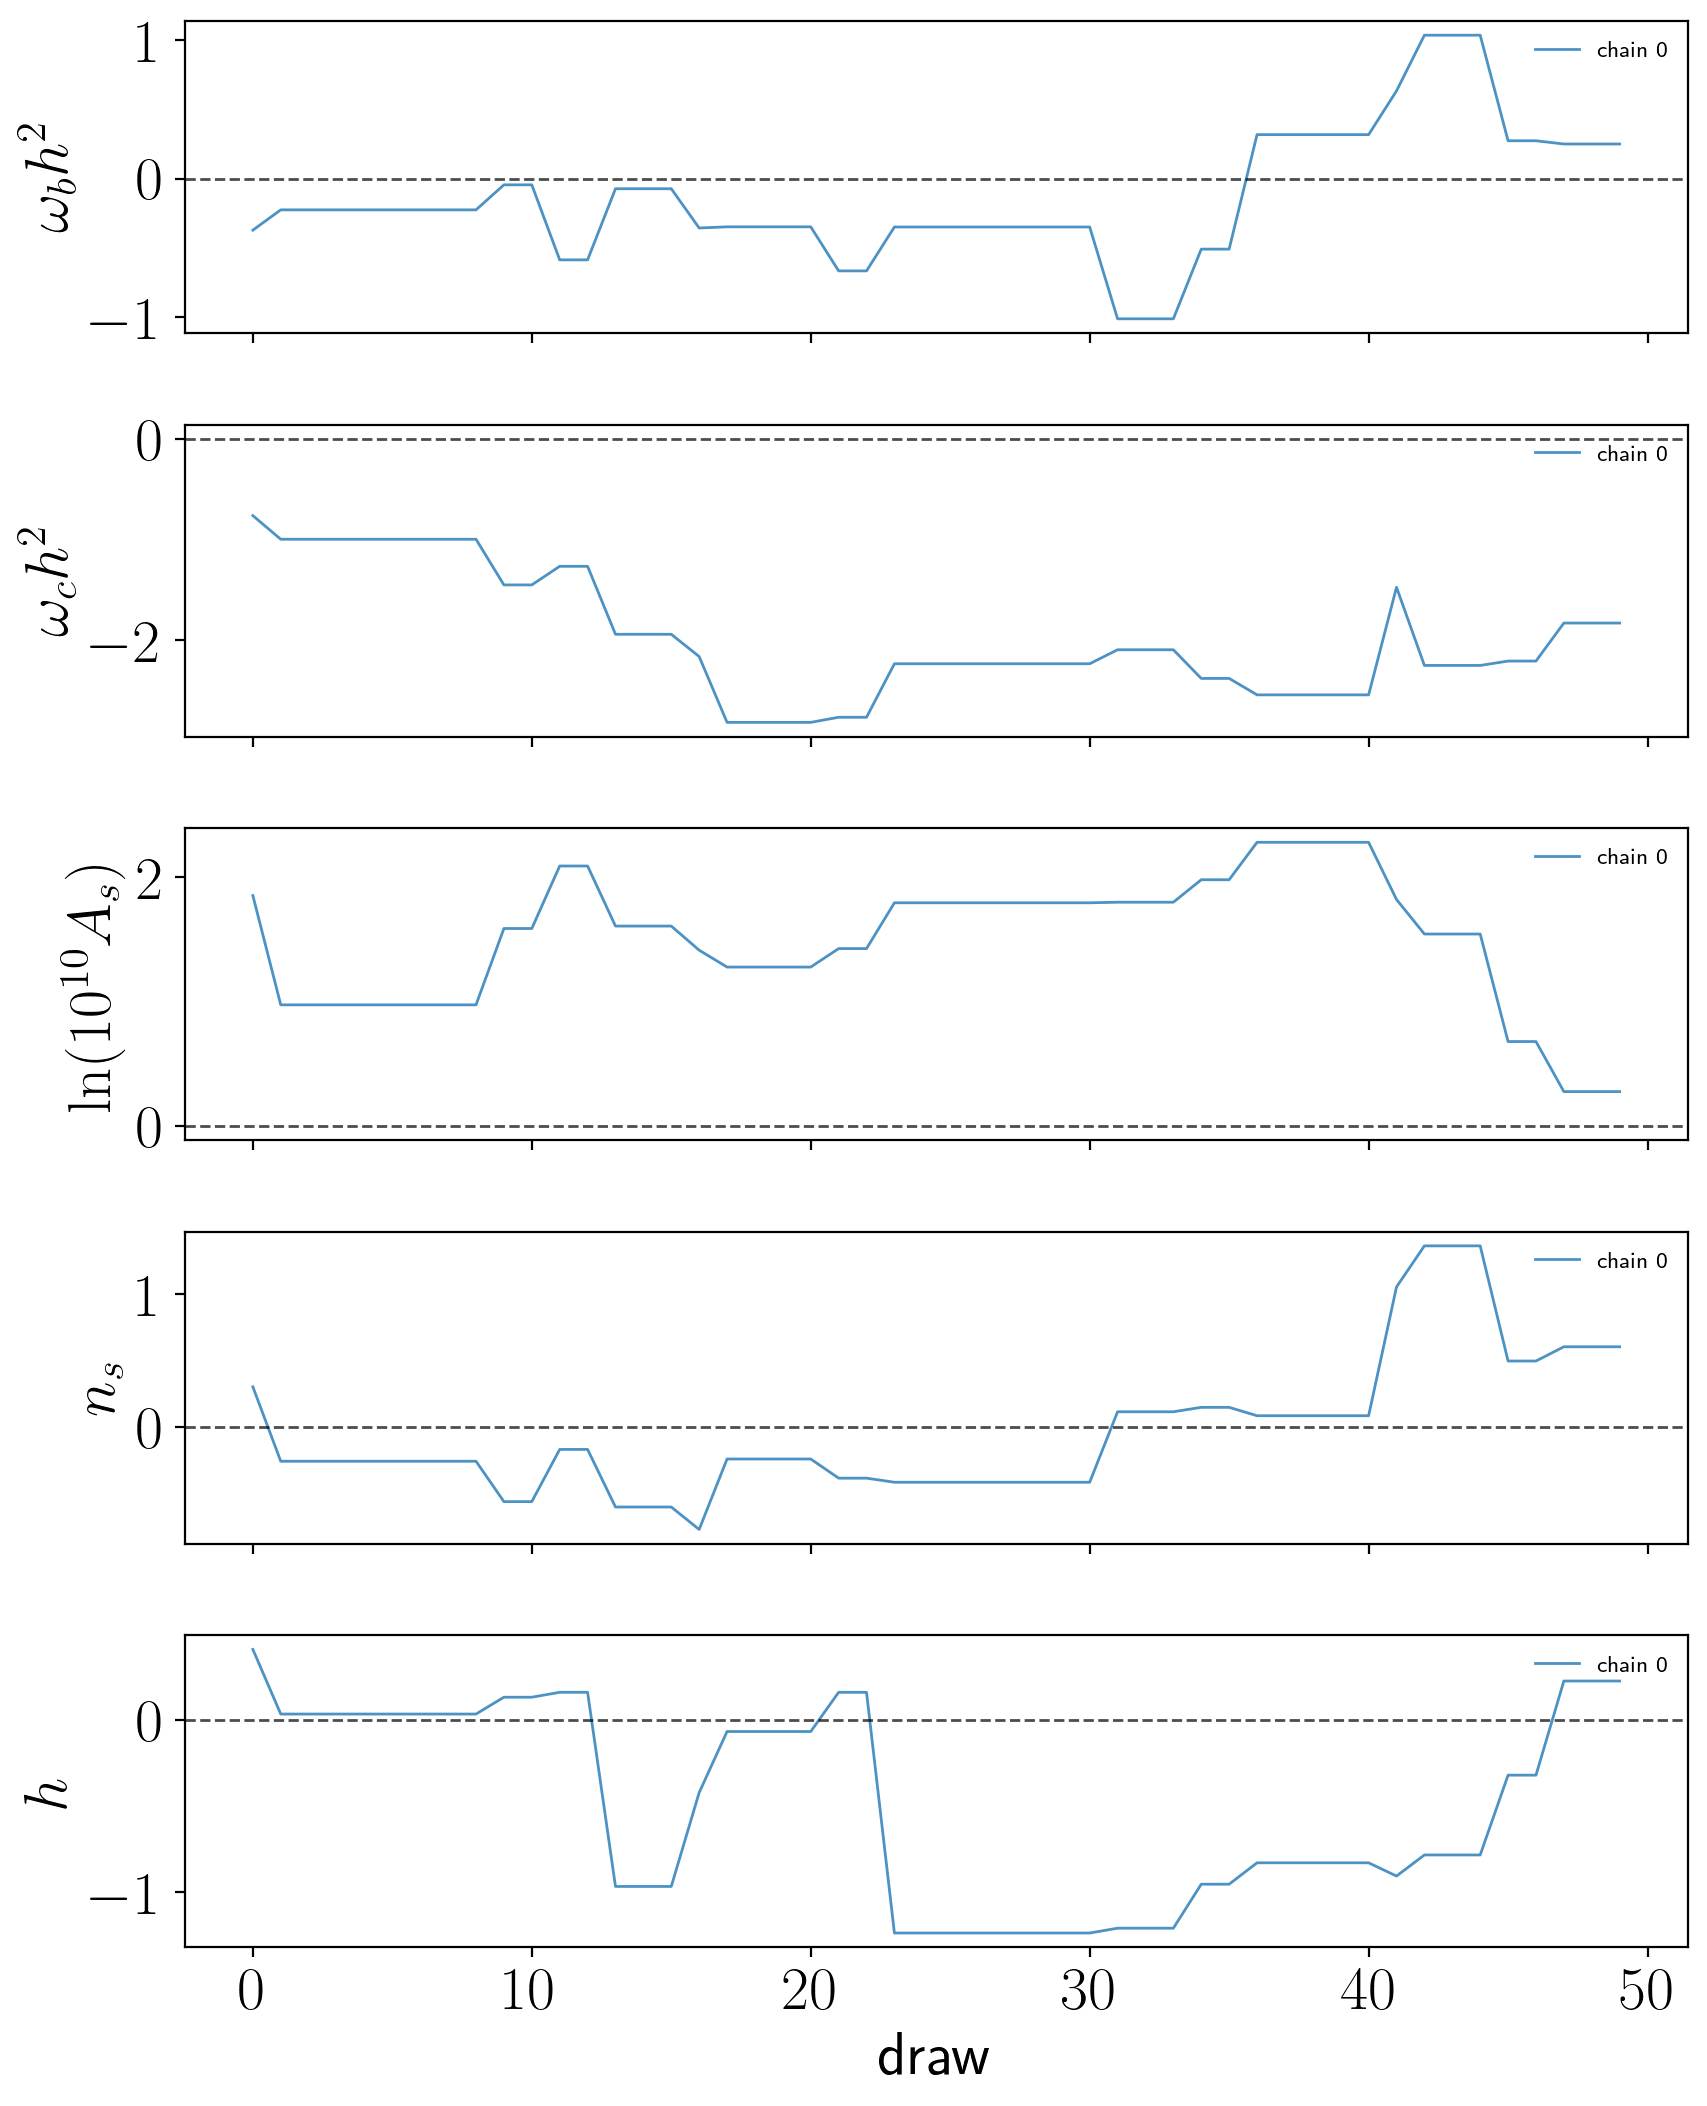

In [13]:
chain_spec = make_fullshape_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, varied_idx=list(split.nl_idx), analysis_kind='joint')
named_w = packed_samples_to_dict(samples_w, chain_spec, chain_axis=0, draw_axis=1)
cosmo_names = [chain_spec.varied_param_names()[i] for i in cosmo_nl_pos]
cosmo_w = {name: named_w[name] for name in cosmo_names}
fig, _ = plot_trace(cosmo_w, var_names=cosmo_names,
                    truths={name: 0.0 for name in cosmo_names},
                    chain_axis=0, draw_axis=1)

## Physical-space posterior and MCMC-vs-Fisher comparison (cosmology)

For exact-target confirmation of these surrogate posteriors, the delayed-acceptance MH chain in `scripts/damh_exact_chain_lcdm.py` samples the exact per-bin posterior directly, and importance-sampling reweighting diagnostics (`ess`, `ess_frac`, `max_weight`) that re-weight a surrogate chain back onto the exact posterior live in `jaxptpolypol.marginal_taylor` (`importance_reweight`, `reweighted_moments`).

In [14]:
samples_phys = samples_to_physical(samples_w, to_physical)
summary = scalar_summary_packed(samples_phys, chain_spec)

cosmo_flat = np.asarray(samples_phys)[..., cosmo_nl_pos].reshape(-1, N_SHARED)
mcmc_mean = cosmo_flat.mean(axis=0)
mcmc_sigma = cosmo_flat.std(axis=0)
mcmc_cov = np.cov(cosmo_flat, rowvar=False)
fisher_cov = np.asarray(inv(F_pfs_bao_prior_cosmo))
fisher_sig = np.sqrt(np.diag(fisher_cov))

print(f"{'param':>7s} {'fid':>10s} {'MCMC mean':>12s} {'Fisher sig':>12s} {'MCMC sig':>12s} {'ratio':>7s}")
for i, key in enumerate(SHARED_KEYS):
    print(f"{key:>7s} {FIDUCIAL_SHARED[i]:10.5g} {mcmc_mean[i]:12.5g} "
          f"{fisher_sig[i]:12.5g} {mcmc_sigma[i]:12.5g} {mcmc_sigma[i]/fisher_sig[i]:7.2f}")

  param        fid    MCMC mean   Fisher sig     MCMC sig   ratio
  ombh2    0.02242     0.022353   0.00047591   0.00022183    0.47
  omch2    0.11933      0.11318    0.0031476    0.0018482    0.59
   logA      3.047       3.1542     0.046819     0.029173    0.62
     ns     0.9665      0.99748     0.025501     0.014828    0.58
      h     0.6766      0.67255    0.0036248    0.0022764    0.63


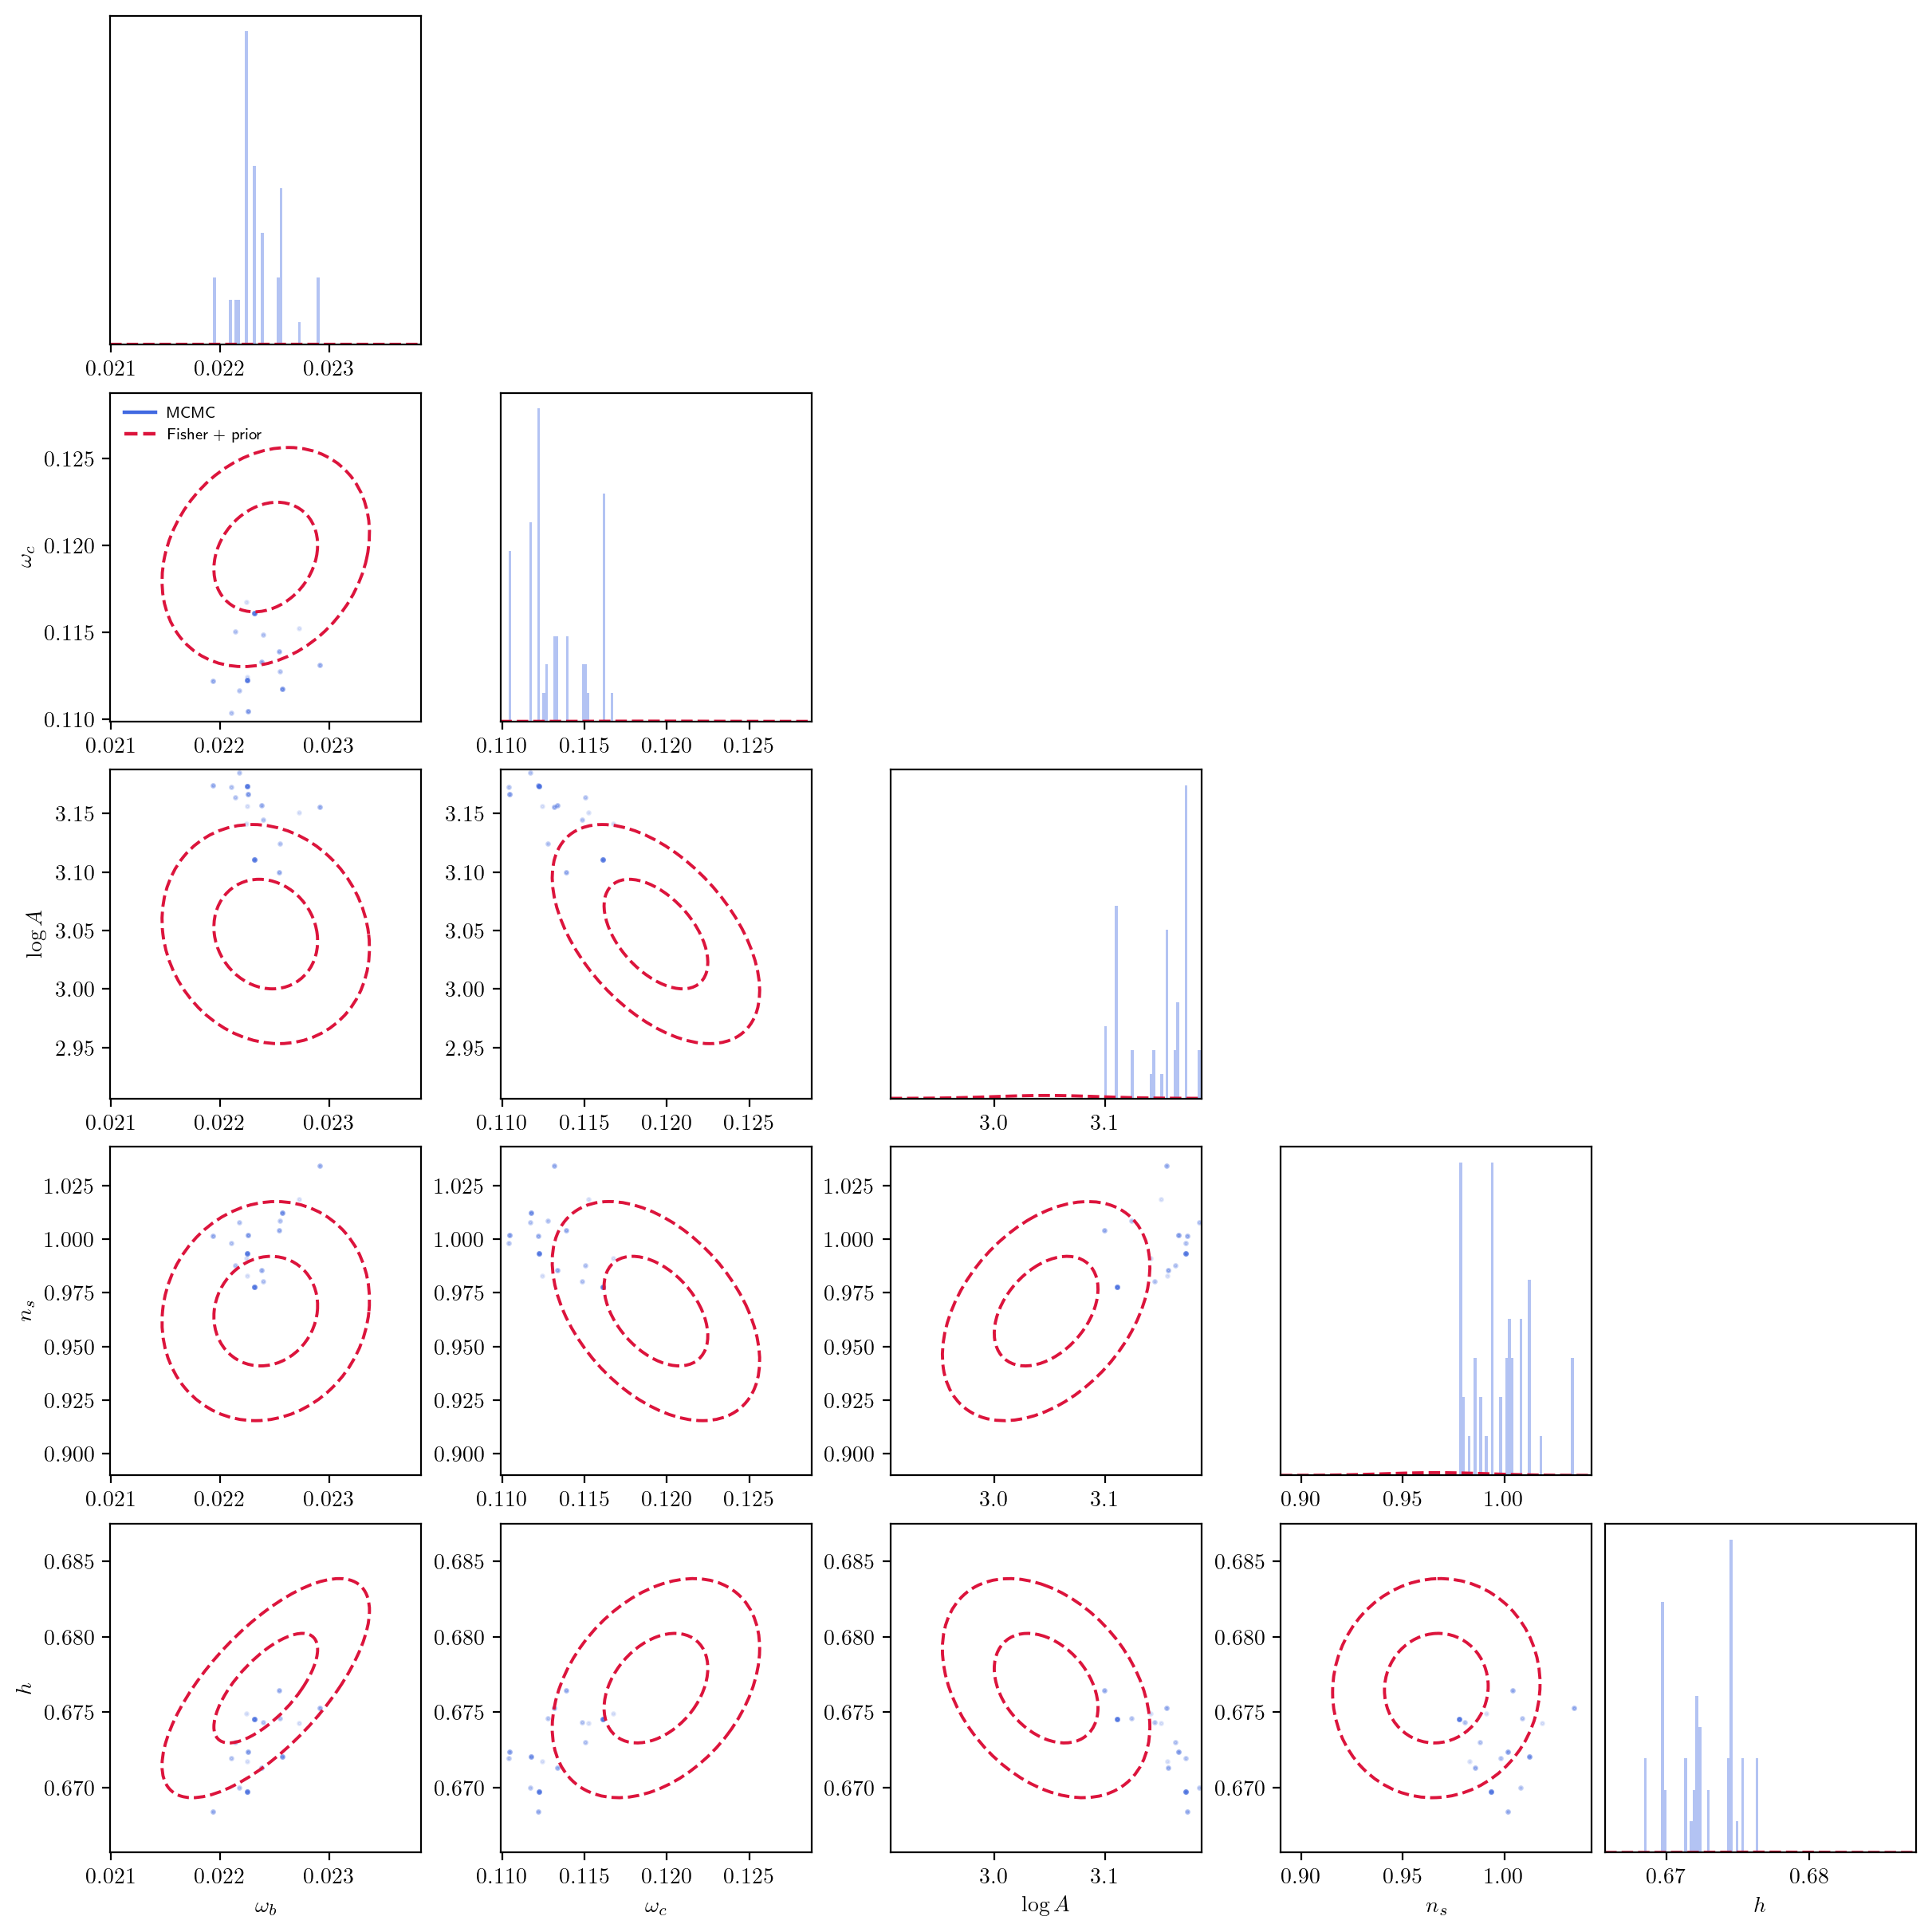

In [15]:
# Cosmology corner: MCMC samples (blue) vs Fisher+prior ellipses (red dashed), both at the fiducial.
plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.4, N_SHARED * 2.4), constrained_layout=True)
handles = [mlines.Line2D([], [], color='royalblue', lw=1.6, label='MCMC'),
           mlines.Line2D([], [], color='crimson', ls='--', lw=1.6, label='Fisher + prior')]
for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)
        if j < i:
            ax.scatter(cosmo_flat[:, j], cosmo_flat[:, i], s=2, alpha=0.15,
                       color='royalblue', rasterized=True)
            plot_contours(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, np.array([j, i]),
                          ax=ax, fill=False, color='crimson', ls='--', lw=1.4)
            if i == 1 and j == 0:
                ax.legend(handles=handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            ax.hist(cosmo_flat[:, i], bins=40, density=True, color='royalblue', alpha=0.4)
            plot_Gaussian(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, i, ax=ax, color='crimson', ls='--', lw=1.4)
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == N_SHARED - 1: ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0: ax.set_ylabel(SHARED_LABELS[i])